# Forced-dissipative barotropic QG beta-plane turbulence


A simulation of forced-dissipative barotropic quasi-geostrophic turbulence on
a beta plane. The dynamics include linear drag and stochastic excitation.

## Install dependencies

First let's make sure we have all required packages installed.

```julia
using Pkg
pkg"add GeophysicalFlows, CUDA, JLD2, CairoMakie, Statistics"
```

## Let's begin
Let's load `GeophysicalFlows.jl` and some other packages we need.

In [1]:
using GeophysicalFlows, CUDA, JLD2, CairoMakie, Random, Printf

using Statistics: mean
using LinearAlgebra: ldiv!

parsevalsum = FourierFlows.parsevalsum
record = CairoMakie.record                # disambiguate between CairoMakie.record and CUDA.record
nothing # hide

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()     # Device (CPU/GPU)
nothing # hide

## Numerical parameters and time-stepping parameters

In [3]:
      n = 128            # 2D resolution: n² grid points
stepper = "FilteredRK4"  # timestepper
     dt = 0.05           # timestep
 nsteps = 8000           # total number of timesteps
 save_substeps = 10      # number of timesteps after which output is saved

nothing # hide

## Physical parameters

In [4]:
L = 2π        # domain size
β = 10.0      # planetary PV gradient
μ = 0.01      # bottom drag
nothing # hide

## Forcing

We force the vorticity equation with stochastic excitation that is delta-correlated in time
and while spatially homogeneously and isotropically correlated. The forcing has a spectrum
with power in a ring in wavenumber space of radius $k_f$ (`forcing_wavenumber`) and width
$δ_f$ (`forcing_bandwidth`), and it injects energy per unit area and per unit time
equal to $\varepsilon$. That is, the forcing covariance spectrum is proportional to
$\exp{[-(|\bm{k}| - k_f)^2 / (2 δ_f^2)]}$.

In [5]:
forcing_wavenumber = 14.0 * 2π/L  # the forcing wavenumber, `k_f`, for a spectrum that is a ring in wavenumber space
forcing_bandwidth  = 1.5  * 2π/L  # the width of the forcing spectrum, `δ_f`
ε = 0.001                         # energy input rate by the forcing

grid = TwoDGrid(dev; nx=n, Lx=L)

K = @. sqrt(grid.Krsq)            # a 2D array with the total wavenumber

forcing_spectrum = @. exp(-(K - forcing_wavenumber)^2 / (2 * forcing_bandwidth^2))
@CUDA.allowscalar forcing_spectrum[grid.Krsq .== 0] .= 0 # ensure forcing has zero domain-average

ε0 = parsevalsum(forcing_spectrum .* grid.invKrsq / 2, grid) / (grid.Lx * grid.Ly)
@. forcing_spectrum *= ε/ε0       # normalize forcing to inject energy at rate ε
nothing # hide

We reset of the random number generator for reproducibility

In [6]:
if dev==CPU(); Random.seed!(1234); else; CUDA.seed!(1234); end
nothing # hide

Next we construct function `calcF!` that computes a forcing realization every timestep.
First we make sure that if `dev=GPU()`, then `CUDA.rand()` function is called for random
numbers uniformly distributed between 0 and 1.

In [7]:
random_uniform = dev==CPU() ? rand : CUDA.rand

function calcF!(Fh, sol, t, clock, vars, params, grid)
  T = eltype(grid)
  @. Fh = sqrt(forcing_spectrum) * cis(2π * random_uniform(T)) / sqrt(clock.dt)

  return nothing
end
nothing # hide

## Problem setup
We initialize a `Problem` by providing a set of keyword arguments.
We use `stepper = "FilteredRK4"`. Filtered timesteppers apply a wavenumber-filter
at every time-step that removes enstrophy at high wavenumbers and, thereby,
stabilize the problem, despite that we use the default viscosity coefficient `ν=0`.

In [8]:
prob = SingleLayerQG.Problem(dev; nx=n, Lx=L, β, μ, dt, stepper,
                             calcF=calcF!, stochastic=true)
nothing # hide

Let's define some shortcuts.

In [9]:
sol, clock, vars, params, grid = prob.sol, prob.clock, prob.vars, prob.params, prob.grid
x,  y  = grid.x,  grid.y
Lx, Ly = grid.Lx, grid.Ly
nothing # hide

First let's see how a forcing realization looks like. Note that when plotting, we decorate
the variable to be plotted with `Array()` to make sure it is brought back on the CPU when
`vars` live on the GPU.

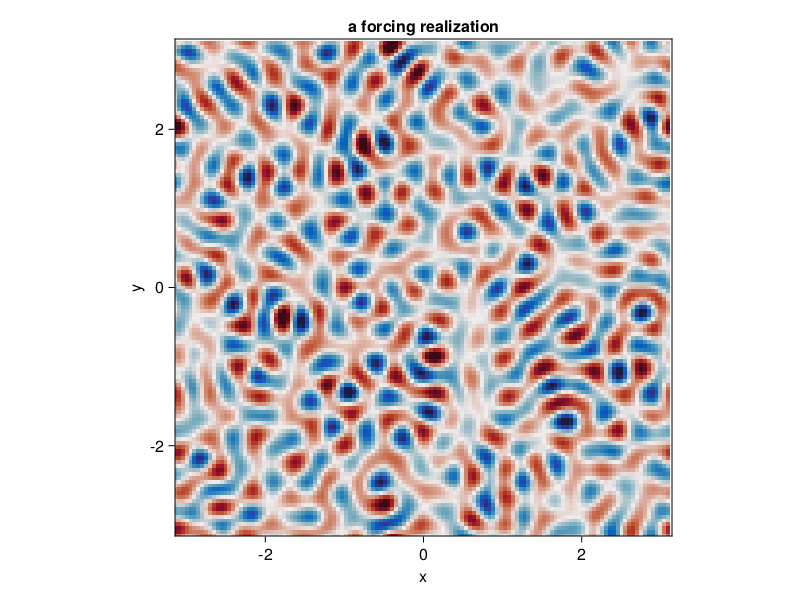

In [10]:
calcF!(vars.Fh, sol, 0.0, clock, vars, params, grid)

fig = Figure()

ax = Axis(fig[1, 1],
          xlabel = "x",
          ylabel = "y",
          aspect = 1,
          title = "a forcing realization",
          limits = ((-Lx/2, Lx/2), (-Ly/2, Ly/2)))

heatmap!(ax, x, y, Array(irfft(vars.Fh, grid.nx));
         colormap = :balance, colorrange = (-8, 8))

fig

## Setting initial conditions

Our initial condition is simply fluid at rest.

In [11]:
SingleLayerQG.set_q!(prob, device_array(dev)(zeros(grid.nx, grid.ny)))

## Diagnostics

Create Diagnostic -- `energy` and `enstrophy` are functions imported at the top.

In [12]:
E = Diagnostic(SingleLayerQG.energy, prob; nsteps, freq=save_substeps)
Z = Diagnostic(SingleLayerQG.enstrophy, prob; nsteps, freq=save_substeps)
diags = [E, Z] # A list of Diagnostics types passed to "stepforward!" will  be updated every timestep.
nothing # hide

## Output

We choose folder for outputing `.jld2` files and snapshots (`.png` files).

In [13]:
filepath = "."
plotpath = "./plots_forcedbetaturb"
plotname = "snapshots"
filename = joinpath(filepath, "singlelayerqg_forcedbeta.jld2")
nothing # hide

Do some basic file management,

In [14]:
if isfile(filename); rm(filename); end
if !isdir(plotpath); mkdir(plotpath); end
nothing # hide

and then create Output.

In [15]:
get_sol(prob) = Array(prob.sol) # extracts the Fourier-transformed solution

function get_u(prob)
  vars, grid, sol = prob.vars, prob.grid, prob.sol

  @. vars.qh = sol

  SingleLayerQG.streamfunctionfrompv!(vars.ψh, vars.qh, params, grid)

  ldiv!(vars.u, grid.rfftplan, -im * grid.l .* vars.ψh)

  return Array(vars.u)
end

output = Output(prob, filename, (:qh, get_sol), (:u, get_u))
nothing # hide

We first save the problem's grid and other parameters so we can use them later.

In [16]:
saveproblem(output)

and then call `saveoutput(output)` once to save the initial state.

In [17]:
saveoutput(output)

## Time-stepping the `Problem` forward

We time-step the `Problem` forward in time.

In [18]:
startwalltime = time()

while clock.step <= nsteps
  if clock.step % 50save_substeps == 0
    cfl = clock.dt * maximum([maximum(vars.u) / grid.dx, maximum(vars.v) / grid.dy])

    log = @sprintf("step: %04d, t: %d, cfl: %.2f, E: %.4f, Q: %.4f, walltime: %.2f min",
    clock.step, clock.t, cfl, E.data[E.i], Z.data[Z.i], (time()-startwalltime)/60)

    println(log)
  end

  stepforward!(prob, diags, save_substeps)
  SingleLayerQG.updatevars!(prob)

  if clock.step % save_substeps == 0
    saveoutput(output)
  end
end

savediagnostic(E, "energy", output.path)
savediagnostic(Z, "enstrophy", output.path)

step: 0000, t: 0, cfl: 0.00, E: 0.0000, Q: 0.0000, walltime: 0.00 min
step: 0500, t: 25, cfl: 0.47, E: 0.0188, Q: 2.6766, walltime: 0.05 min
step: 1000, t: 50, cfl: 0.58, E: 0.0288, Q: 2.6773, walltime: 0.08 min
step: 1500, t: 75, cfl: 0.95, E: 0.0362, Q: 2.7047, walltime: 0.12 min
step: 2000, t: 100, cfl: 0.83, E: 0.0399, Q: 2.5734, walltime: 0.15 min
step: 2500, t: 125, cfl: 0.85, E: 0.0432, Q: 2.8344, walltime: 0.19 min
step: 3000, t: 150, cfl: 0.77, E: 0.0438, Q: 2.5116, walltime: 0.22 min
step: 3500, t: 175, cfl: 0.80, E: 0.0455, Q: 2.5815, walltime: 0.25 min
step: 4000, t: 200, cfl: 0.80, E: 0.0458, Q: 2.5701, walltime: 0.29 min
step: 4500, t: 225, cfl: 0.78, E: 0.0465, Q: 2.5623, walltime: 0.32 min
step: 5000, t: 250, cfl: 0.75, E: 0.0465, Q: 2.4738, walltime: 0.36 min
step: 5500, t: 275, cfl: 0.79, E: 0.0464, Q: 2.5337, walltime: 0.40 min
step: 6000, t: 300, cfl: 0.82, E: 0.0459, Q: 2.4495, walltime: 0.44 min
step: 6500, t: 325, cfl: 0.79, E: 0.0476, Q: 2.7472, walltime: 0.48 m

## Load saved output and visualize

We now have output from our simulation saved in `singlelayerqg_forcedbeta.jld2` which
we can load to create a time series for the fields we are interested in.

In [19]:
file = jldopen(output.path)

iterations = parse.(Int, keys(file["snapshots/t"]))
t = [file["snapshots/t/$i"] for i ∈ iterations]

qh = [file["snapshots/qh/$i"] for i ∈ iterations]
u  = [file["snapshots/u/$i"] for i ∈ iterations]

E_t  = file["diagnostics/energy/t"]
Z_t  = file["diagnostics/enstrophy/t"]
E_data = file["diagnostics/energy/data"]
Z_data = file["diagnostics/enstrophy/data"]

x,  y  = file["grid/x"],  file["grid/y"]
nx, ny = file["grid/nx"], file["grid/ny"]
Lx, Ly = file["grid/Lx"], file["grid/Ly"]

close(file)

We create a figure using Makie's [`Observable`](https://makie.juliaplots.org/stable/documentation/nodes/)s

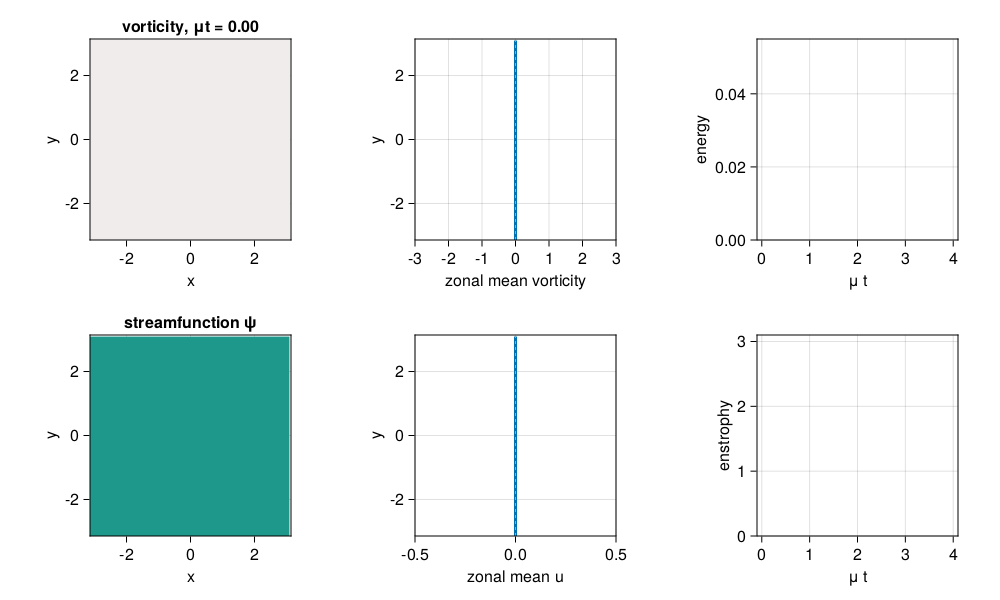

In [20]:
j = Observable(1)

q = @lift irfft(qh[$j], nx)
ψ = @lift irfft(- Array(grid.invKrsq) .* qh[$j], nx)
q̄ = @lift real(ifft(qh[$j][1, :] / ny))
ū = @lift vec(mean(u[$j], dims=1))

title_q = @lift @sprintf("vorticity, μt = %.2f", μ * t[$j])

energy = Observable([Point2f(E_t[1], E_data[1])])
enstrophy = Observable([Point2f(Z_t[1], Z_data[1])])

fig = Figure(resolution=(1000, 600))

axis_kwargs = (xlabel = "x",
               ylabel = "y",
               aspect = 1,
               limits = ((-Lx/2, Lx/2), (-Ly/2, Ly/2)))

axq = Axis(fig[1, 1]; title = title_q, axis_kwargs...)

axψ = Axis(fig[2, 1]; title = "streamfunction ψ", axis_kwargs...)

axq̄ = Axis(fig[1, 2],
           xlabel = "zonal mean vorticity",
           ylabel = "y",
           aspect = 1,
           limits = ((-3, 3), (-Ly/2, Ly/2)))

axū = Axis(fig[2, 2],
           xlabel = "zonal mean u",
           ylabel = "y",
           aspect = 1,
           limits = ((-0.5, 0.5), (-Ly/2, Ly/2)))

axE = Axis(fig[1, 3],
           xlabel = "μ t",
           ylabel = "energy",
           aspect = 1,
           limits = ((-0.1, 4.1), (0, 0.055)))

axZ = Axis(fig[2, 3],
           xlabel = "μ t",
           ylabel = "enstrophy",
           aspect = 1,
           limits = ((-0.1, 4.1), (0, 3.1)))

heatmap!(axq, x, y, q;
         colormap = :balance, colorrange = (-8, 8))

levels = collect(-0.32:0.04:0.32)

contourf!(axψ, x, y, ψ;
          levels, colormap = :viridis, colorrange = (-0.22, 0.22))
contour!(axψ, x, y, ψ;
         levels, color = :black)

lines!(axq̄, q̄, y; linewidth = 3)
lines!(axq̄, 0y, y; linewidth = 1, linestyle=:dash)

lines!(axū, ū, y; linewidth = 3)
lines!(axū, 0y, y; linewidth = 1, linestyle=:dash)

lines!(axE, energy; linewidth = 3)
lines!(axZ, enstrophy; linewidth = 3, color = :red)

fig

We are now ready to animate all saved output.

In [21]:
frames = 1:length(t)
record(fig, "singlelayerqg_betaforced.mp4", frames, framerate = 18) do i
  j[] = i

  energy[] = push!(energy[], Point2f(μ * E_t[i], E_data[i]))
  enstrophy[] = push!(enstrophy[], Point2f(μ * Z_t[i], Z_data[i]))
end
nothing # hide

![](singlelayerqg_betaforced.mp4)

In [22]:
# we delete the .jld2 file before deploying the docs (takes too much space) #hide
rm(output.path) #hide

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*